In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,3,6'

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte
from network import shard
from consts import *

Load a (pre-processed) dataset
---

In [3]:
# Load volumetric fields 
dataset = xr.load_dataset('../../data/RADMC3D_input_files/dataset_spherical.nc')
number_density = jnp.array(dataset.numberdens_12c16o)
temperature = jnp.array(dataset.dust_temperature)
velocity = jnp.array(dataset.gas_velocity)

Define a "camera" (geomtery / spectrum)
---

In [5]:
r, theta, phi = grid.read_spherical_amr('../../data/RADMC3D_input_files/amr_grid.inp')
bbox = [(phi[0], phi[-1]), (theta[0], theta[-1]), (np.log10(r[0]), np.log10(r[-1]))]
z_width = 2*r[-1]*np.cos(theta.min())

# Define sensor parameters
projection = {
    'npix': 384,
    'nray': 500,
    'incl': 45.0,
    'phi': 100.0,
    'posang': 0.0, 
    'fov': np.float32(1.1) * 2*r[-1],  # Note: float32 is to match radmc3d exact pixel grid
    'z_width': z_width                 # width of the disk 
}
pixel_area = (projection['fov'] / projection['npix'])**2
ray_coords, obs_dir = sensor.orthographic_projection(**projection)
ray_coords_sph = grid.cartesian_to_spherical(ray_coords, logr=True)

Line radiative transfer
---

In [ ]:
# Interpolate dataset along the (spherical) ray coordinates
gas_nd = grid.interpolate_scalar(number_density, ray_coords_sph, bbox)
gas_t  = grid.interpolate_scalar(temperature, ray_coords_sph, bbox, cval=float(temperature.min()))

# Einstein coefficient for spontaneous emission from level u to level d
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path='../../data/RADMC3D_input_files/molecule_12c16o.inp')
nu0, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions)
n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions)
print('line frequency: {} Ghz'.format(nu0/ghz))

In [ ]:
# Compute line radiative transfer for a whole spectral cube
width_kms = 3.65
linenlam = 50
alpha_turb = 0.0
camera_freqs = sensor.compute_camera_freqs(linenlam, width_kms, nu0)

gas_v = grid.interpolate_vector(velocity, ray_coords, ray_coords_sph, bbox)

# Define a parallel mapping over several gpus
pmap = jax.pmap(line_rte.compute_spectral_cube,
                axis_name='freq', 
                in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None))

print('computing spectral cube for a total of {} frequencies'.format(camera_freqs.size))
images = pmap(shard(camera_freqs), gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area, alpha_turb)
images = images.reshape(linenlam, projection['npix'], projection['npix'])

interactive(children=(IntSlider(value=24, description='frame', max=49), Output()), _dom_classes=('widget-inter…

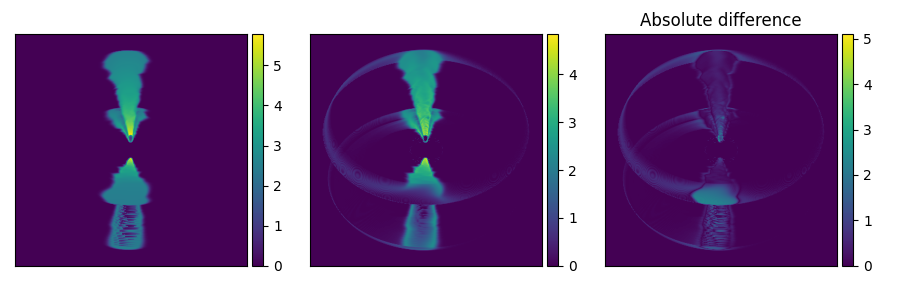

In [8]:
import disksurf
cube = disksurf.observation('../../data/image_test.fits')

%matplotlib widget
visualization.slider_frame_comparison(cube.data, images)